In [1]:
%pip install prophet

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import joblib

In [3]:
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv')
df.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB


In [5]:
df.isna().sum()

date     0
sales    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['date'] = pd.to_datetime(df['date'])

In [8]:
df.set_index('date', inplace=True)
# si la columna de ventas se llama 'sales':
ts = df['sales']

In [9]:
df.head()

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 17:10:08.079328 to 2023-09-03 17:10:08.079328
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


1. Verificar orden temporal y tensor (frecuencia)

In [11]:
df = df.sort_index()
df.index.to_series().diff().value_counts()

date
1 days    365
Name: count, dtype: int64

La serie tiene frecuencia diaria (tensor diario)

2. Graficar la serie para ver su forma general

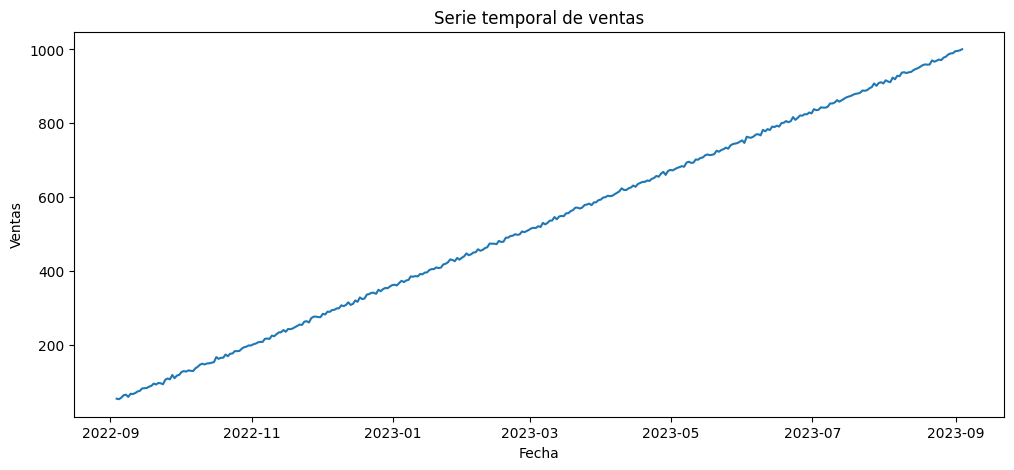

In [12]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

La serie muestra una tendencia creciente. Esto indica que las ventas han aumentado de forma continue durante el período analizado. 

3. Cálculo de media móvil para detectar la tendencia

qué hace una media móvil en la práctica? 
- suaviza la serie (elimina ruido diario --> subidas y bajadas pequenas)
- Resalta la forma general: permite ver con mas claridad si la serie sube, baja o se mantiene. 
- Permite detectar cambios de ritmo: si la pendiente de la media movil se acelera o se aplana. 

In [13]:
rolling_mean = ts.rolling(window=7).mean()

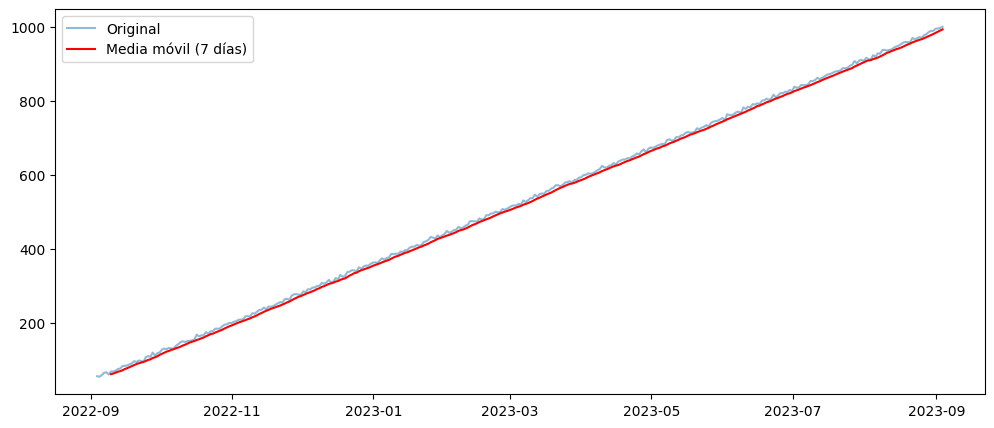

In [14]:
plt.figure(figsize=(12,5))
plt.plot(ts, label="Original", alpha=0.5)
plt.plot(rolling_mean, label="Media móvil (7 días)", color="red")
plt.legend()
plt.show()

La serie muestra una tendencia creciente sostenida. Patrón de crecimiento estable con poca variabilidad y sin estacionalidad evidente. 

4. Test de estacionariedad

In [16]:
result = adfuller(ts.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f"Critical Value ({key}): {value:.3f}")

ADF Statistic: 0.545414193706378
p-value: 0.9861899815311064
Critical Value (1%): -3.449
Critical Value (5%): -2.870
Critical Value (10%): -2.571


No se rechaza hipotesis nula. Serie NO estacionaria. (P value > 0.05)

5. Diferenciar la serie para eliminar la tendencia

In [17]:
ts_diff = ts.diff().dropna()
ts_diff.head()

date
2022-09-04 17:10:08.079328   -1.488946
2022-09-05 17:10:08.079328    4.338482
2022-09-06 17:10:08.079328    6.389205
2022-09-07 17:10:08.079328    1.482734
2022-09-08 17:10:08.079328   -5.931768
Name: sales, dtype: float64

6. Comprobar si la serie diferenciada ya es estacionaria (ADF)

In [18]:
result_diff = adfuller(ts_diff)
print("ADF Statistic (diff):", result_diff[0])
print("p-value (diff):", result_diff[1])
for key, value in result_diff[4].items():
    print(f"Critical Value ({key}): {value:.3f}")

ADF Statistic (diff): -9.430263118334729
p-value (diff): 5.212954111417404e-16
Critical Value (1%): -3.449
Critical Value (5%): -2.870
Critical Value (10%): -2.571


Se rechaza hipotesis nula. La serie diferenciada si es estacionaria. 

7. Entrenar ARIMA 

7.1 elegir parámetros p y q

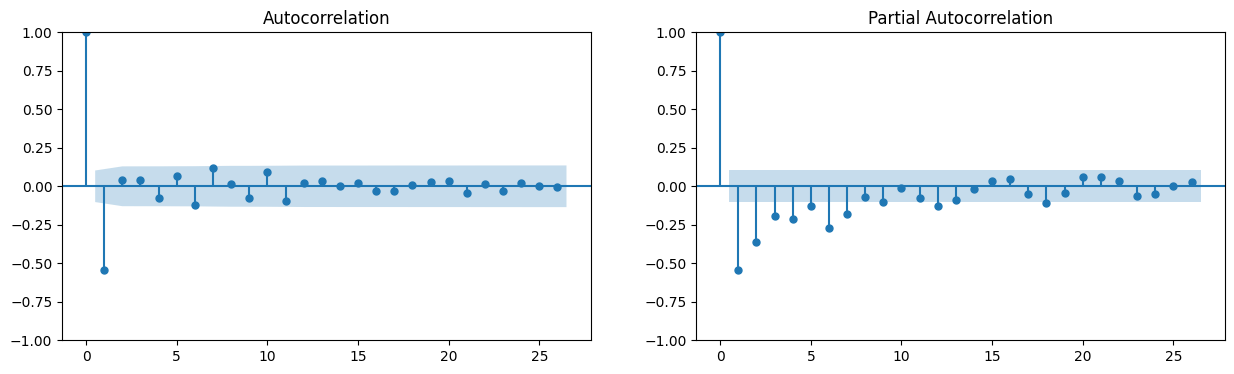

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15,4))
plot_acf(ts_diff, ax=axes[0])
plot_pacf(ts_diff, ax=axes[1])
plt.show()

7.2 Probar modelos candidatos para elegir p y q 

In [23]:
orders = [(1,1,1), (2,1,1), (3,1,1)]

for order in orders:
    model = ARIMA(ts, order=order)
    model_fit = model.fit()
    print(f"ARIMA{order} - AIC: {model_fit.aic}")

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(1, 1, 1) - AIC: 2104.4592900620937


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-i

ARIMA(2, 1, 1) - AIC: 1980.1077833857712


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA(3, 1, 1) - AIC: 1932.5320880190404


/home/vscode/.local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Train test split

In [24]:
split_point = int(len(ts) * 0.8)
train = ts.iloc[:split_point]
test = ts.iloc[split_point:]

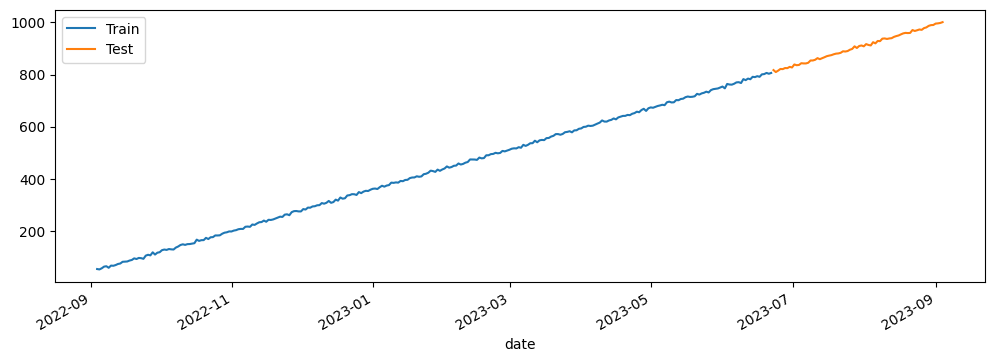

In [25]:
train.plot(figsize=(12,4), label="Train")
test.plot(label="Test")
plt.legend()
plt.show()

In [26]:
model = ARIMA(train, order=(3,1,1))
model_fit = model.fit()
print(model_fit.summary())

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(3, 1, 1)   Log Likelihood                -772.337
Date:                Sun, 04 Jan 2026   AIC                           1554.673
Time:                        14:26:36   BIC                           1573.040
Sample:                    09-03-2022   HQIC                          1562.031
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2831      0.053      5.332      0.000       0.179       0.387
ar.L2          0.3795      0.058      6.543      0.000       0.266       0.493
ar.L3          0.3373      0.062      5.426      0.0

In [27]:
forecast = model_fit.forecast(steps=len(test))

In [29]:
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 2.931360918285647


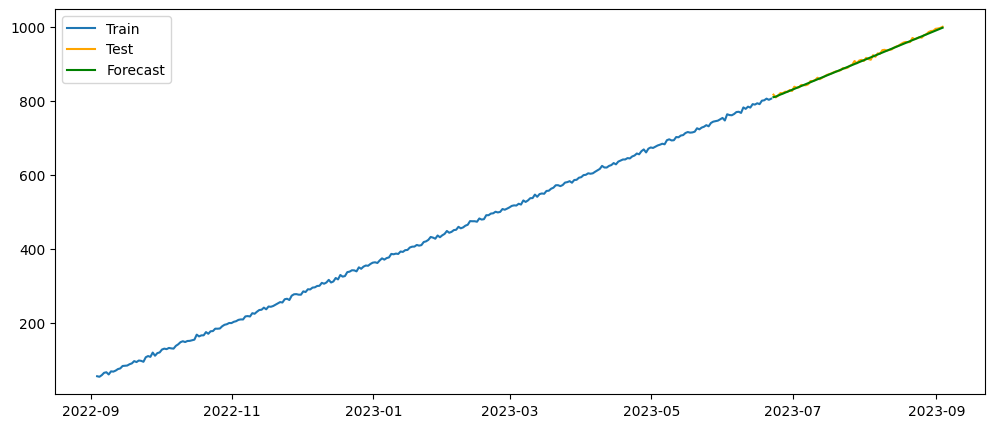

In [30]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test", color="orange")
plt.plot(forecast, label="Forecast", color="green")
plt.legend()
plt.show()

Conclusión:

La serie original tenía una tendencia clara, así que no era estacionaria. Después de diferenciarla una vez, la serie se volvió estable y pudimos usar un modelo ARIMA con d=1. Probamos varios modelos y ARIMA(3,1,1) fue el mejor según el AIC. Al evaluarlo con datos de test, obtuvo un RMSE bajo y las predicciones siguieron muy bien los valores reales. En resumen, el modelo funciona bien y es adecuado para hacer predicciones a corto plazo

In [32]:
joblib.dump(model_fit,"modelo_arima.pkl")

['modelo_arima.pkl']